In [1]:

import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial import cKDTree
import torch
import thomas_npe as T    
SEED = 42
RNG  = np.random.default_rng(SEED)
torch.manual_seed(SEED)

# Set matplotlib parameters for academic publication
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "text.usetex": True, # Requires LaTeX installation
})


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ModuleNotFoundError: No module named 'thomas_npe'

---
## 1 · The Thomas Cluster Process

### 1.1 Generative model

The **Thomas (Neyman–Scott) process** \[Thomas 1949; Neyman & Scott 1958\]
is a hierarchical spatial point process defined by two steps:

1. Scatter $N_{\text{parent}} \sim \text{Poisson}(\lambda_p)$
   **cluster centres** uniformly in $[0,1]^2$.

2. Around each centre $\mathbf{c}_j$, generate
   $N_j \sim \text{Poisson}(\mu)$ **galaxies** at positions

$$
\mathbf{x}_{jk} = \mathbf{c}_j + \boldsymbol{\varepsilon}_{jk},
\qquad
\boldsymbol{\varepsilon}_{jk} \sim \mathcal{N}\!\left(\mathbf{0},\,\sigma^2 \mathbf{I}\right).
$$

We **fix** $\lambda_p = 20$ and **infer** $(\mu, \sigma)$ from the galaxy
positions.


### 1.2 Known power spectrum

The two-point power spectrum of the Thomas process is:

$$
P_{\text{Thomas}}(k) = \frac{1}{\lambda_p}
\!\left[1 + \lambda_p \mu^2 \exp\!\left(-k^2 \sigma^2\right)\right].
$$

This tells us:
- $\mu$ raises the **large-scale amplitude** (more galaxies per cluster).
- $\sigma$ sets the **roll-off scale** (wider clusters decay at lower $k$).

### 1.3 Physical analogy

| Thomas parameter | Physical analogue |
|-----------------|-------------------|
| $\lambda_p$ | Halo number density |
| $\mu$ | Mean halo occupation $\langle N \mid M \rangle$ (HOD) |
| $\sigma$ | Halo virial radius / concentration |

### 1.4 Prior

We place a uniform prior over the inference parameters:

$$
\mu \sim \mathcal{U}[3, 25], \qquad
\sigma \sim \mathcal{U}[0.02, 0.12].
$$

In [ ]:
# ── Inspect the module constants ──────────────────────────────────────────────
print(f"Fixed parent count  λ_p = {T.LAMBDA_P}")
print(f"Prior on μ           : [{T.MU_LO},  {T.MU_HI}]")
print(f"Prior on σ           : [{T.SIG_LO}, {T.SIG_HI}]")

Fixed parent count  λ_p = 20
Prior on μ           : [3.0,  25.0]
Prior on σ           : [0.02, 0.12]


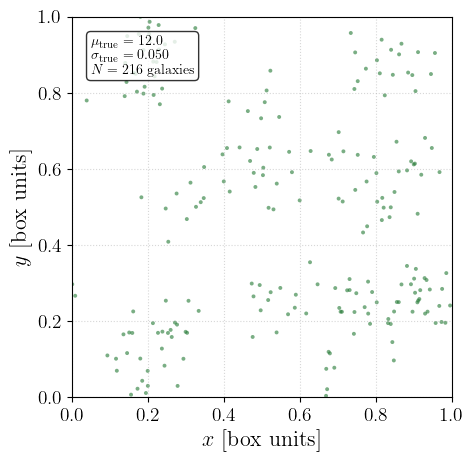

In [ ]:
MU_TRUE    = 12.0
SIGMA_TRUE = 0.050

# Simulate the "observed" catalog
rng_obs = np.random.default_rng(123)          # held-out seed
x_obs   = T.simulate_thomas(MU_TRUE, SIGMA_TRUE, rng_obs)

fig, ax = plt.subplots(figsize=(5, 5))

# Use a professional color and finer point marker
ax.scatter(x_obs[:, 0], x_obs[:, 1], s=8, alpha=0.6, c="#227833", edgecolor='none')

# Configure axes for clarity
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_xlabel(r"$x$ [box units]")
ax.set_ylabel(r"$y$ [box units]")

# Add a subtle grid
ax.grid(True, linestyle=':', alpha=0.5)

# Add informative annotation inside the plot instead of a title
text_str = (r"$\mu_{\rm true} = 12.0$" + "\n" +
            r"$\sigma_{\rm true} = 0.050$" + "\n" +
            r"$N = " + str(len(x_obs)) + "$ galaxies")

ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# plt.savefig("mock_observation.pdf", bbox_inches='tight', dpi=300)
plt.show()

### 1.6 Exploring the parameter space — **Figure 1**

How do the catalogs look across different $(\mu, \sigma)$ values?
More $\mu$ → denser clusters. Larger $\sigma$ → more diffuse clusters.

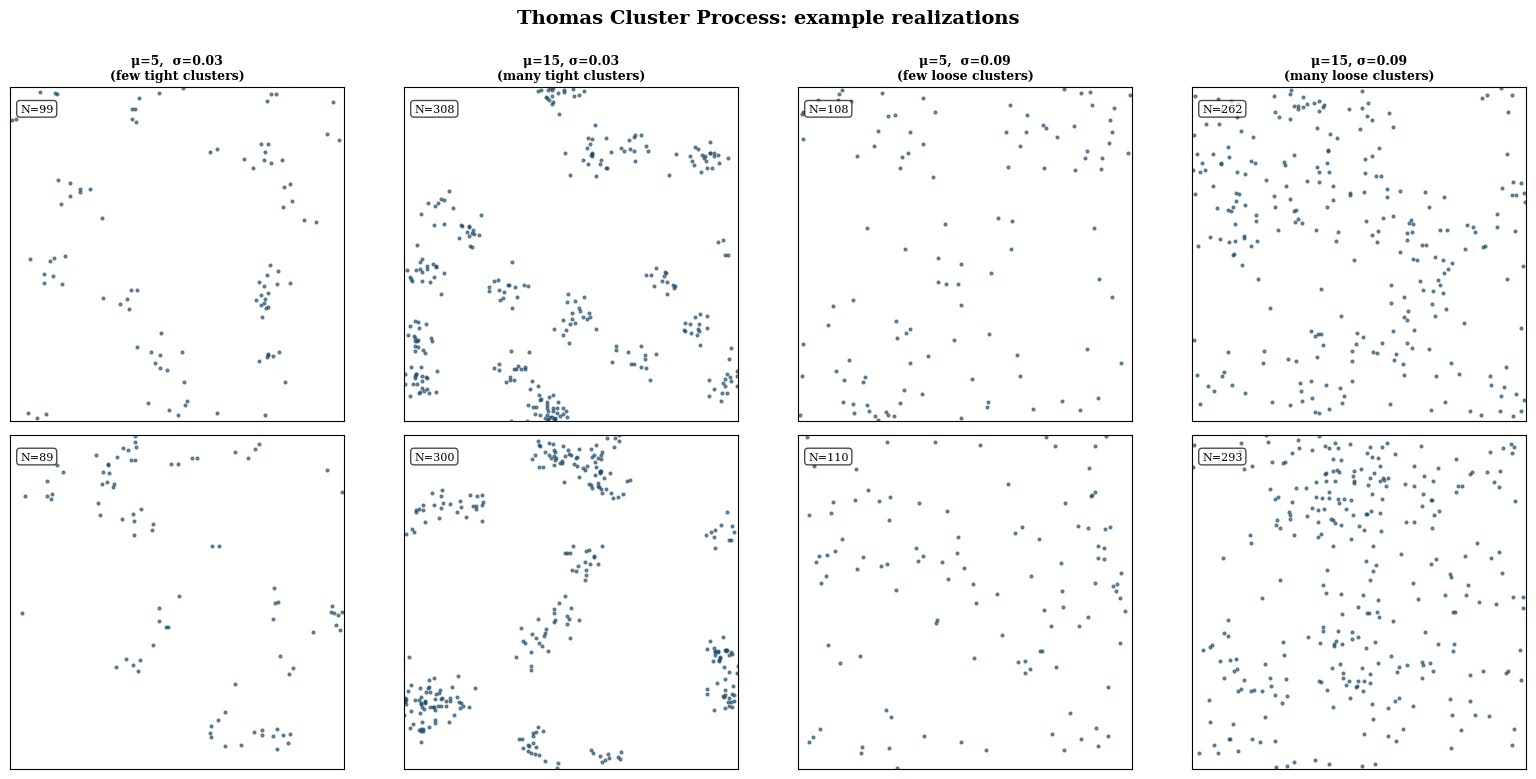

Saved: 1_example_catalogs.pdf


<Figure size 640x480 with 0 Axes>

In [ ]:
# ── Figure 1: Thomas process parameter space exploration ───────────────────────
plt.rcParams['text.usetex'] = False
fig = T.plot_example_catalogs(RNG)

plt.tight_layout(pad=1.5)
plt.show()

In [ ]:
# ============================================================
# Train NPE on raw catalogs (full positional information)
# ============================================================
import time
import numpy as np
import torch
from tqdm import tqdm

N_TRAIN = 5000
N_MAX = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def prepare_catalog(cat, n_max=100):
    cat = np.array(cat, dtype=np.float32)
    padded = np.zeros((n_max, 2), dtype=np.float32)
    n_pts = min(len(cat), n_max)
    padded[:n_pts] = cat[:n_pts]
    return padded.flatten()   # shape (200,)

print("Generating training data ...")
theta_train = []
catalog_train = []
rng = np.random.default_rng(42)

for _ in tqdm(range(N_TRAIN)):
    # FIX BUG 1: use T module prior bounds so T.train_flow normalisation,
    # T.unnormalise, and T.sbc_validation all operate on the same range.
    mu    = np.random.uniform(T.MU_LO,  T.MU_HI)
    sigma = np.random.uniform(T.SIG_LO, T.SIG_HI)
    cat = T.simulate_thomas(mu, sigma, rng)
    theta_train.append([mu, sigma])
    catalog_train.append(prepare_catalog(cat))

theta_train = np.array(theta_train, dtype=np.float32)
catalog_train = np.array(catalog_train)   # shape (N_TRAIN, 200)

# Define and train the flow
context_dim = 200
flow = T.RealNVP(context_dim=context_dim, hidden=128, n_layers=5)
flow.to(DEVICE)

print("Training NPE ...")
losses = T.train_flow(
    flow,
    theta_train,
    catalog_train,
    n_epochs=1000,
    batch_size=128,
    lr=3e-4,
    device=DEVICE
)

# Optional: save the model for later use
torch.save(flow.state_dict(), "field_npe.pt")

Generating training data ...


100%|██████████| 5000/5000 [00:00<00:00, 59422.03it/s]

Training NPE ...


  Epoch   50/1000: loss = 0.8754   lr = 2.98e-04
  Epoch  100/1000: loss = 0.5788   lr = 2.93e-04
  Epoch  150/1000: loss = 0.3010   lr = 2.84e-04
  Epoch  200/1000: loss = 0.1558   lr = 2.72e-04
  Epoch  250/1000: loss = -0.1004   lr = 2.58e-04
  Epoch  300/1000: loss = -0.3238   lr = 2.40e-04
  Epoch  350/1000: loss = -0.3502   lr = 2.21e-04
  Epoch  400/1000: loss = -0.6322   lr = 2.00e-04
  Epoch  450/1000: loss = -0.8078   lr = 1.78e-04
  Epoch  500/1000: loss = -0.9136   lr = 1.55e-04
  Epoch  550/1000: loss = -1.1989   lr = 1.32e-04
  Epoch  600/1000: loss = -1.3652   lr = 1.10e-04
  Epoch  650/1000: loss = -1.4851   lr = 8.92e-05
  Epoch  700/1000: loss = -1.7179   lr = 6.98e-05
  Epoch  750/1000: loss = -1.8538   lr = 5.25e-05
  Epoch  800/1000: loss = -1.9584   lr = 3.77e-05
  Epoch  850/1000: loss = -2.0853   lr = 2.58e-05
  Epoch  900/1000: loss = -2.1518   lr = 1.71e-05
  Epoch  950/1000: loss = -2.2127   lr = 1.18e-05
  Epoch 1000/1000: loss = -2.2286   lr = 1.00e-05


In [ ]:
# ============================================================
# NPE posterior samples (field‑level)
# ============================================================
obs_flat = prepare_catalog(x_obs)                 # shape (200,)
obs_tensor = torch.from_numpy(obs_flat).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    samples_npe_field = flow.sample(context=obs_tensor, n_samples=5000).cpu().numpy()

print("NPE field‑level samples shape:", samples_npe_field.shape)
# FIX BUG 2: flow outputs in normalised [-1,1] space; convert to physical.
samples_npe_field = T.unnormalise(samples_npe_field)
print("NPE field-level samples (physical) μ range: ", samples_npe_field[:,0].min().round(2), "–", samples_npe_field[:,0].max().round(2))


NPE field‑level samples shape: (5000, 2)


---
## 3 · Generating Training Data

For each training simulation $i = 1, \ldots, N_{\text{train}}$:

1. Draw $(\mu_i, \sigma_i) \sim \mathcal{U}[\text{prior}]$.
2. Simulate catalog $\{x_j\}_i \sim \text{Thomas}(\mu_i, \sigma_i)$.
3. Compute $\mathbf{s}_i = \text{summary}(\{x_j\}_i)$.
4. Normalise $(\mu_i, \sigma_i) \to [-1,1]^2$.

The training set is therefore $\{(\tilde{\theta}_i, \mathbf{s}_i)\}_{i=1}^{N}$,
where $\tilde\theta$ denotes the normalised parameters.

## 4 · The Normalizing Flow — Real-NVP

In [ ]:
def analytical_pk(k, mu, sigma, rho=1.0):
    """
    Theoretical Power Spectrum for a Thomas Process.
    rho: density of parent clusters (needs to be known/fixed)
    """
    return (mu / rho) * (1 + mu * np.exp(-k**2 * sigma**2))

In [ ]:
from scipy.spatial import cKDTree

def compute_power_spectrum(catalog, L=1.0, bins=20):
    """
    Computes P(k) using the Landy-Szalay estimator.
    """
    n_points = len(catalog)
    # Generate random points for normalization
    n_random = n_points * 10
    random_catalog = np.random.rand(n_random, 2) * L 

    r_bins = np.linspace(0, L/2, bins + 1)
    
    # Count pairs
    tree_data = cKDTree(catalog, boxsize=L)
    tree_rand = cKDTree(random_catalog, boxsize=L)
    
    def count_pairs(tree1, tree2, r_bins):
        return tree1.count_neighbors(tree2, r_bins[1:]) - tree1.count_neighbors(tree2, r_bins[:-1])

    DD = count_pairs(tree_data, tree_data, r_bins)
    RR = count_pairs(tree_rand, tree_rand, r_bins)
    DR = count_pairs(tree_data, tree_rand, r_bins)
    
    # Normalize
    n_D, n_R = n_points, n_random
    dd_n = DD / (n_D * (n_D - 1) / 2)
    rr_n = RR / (n_R * (n_R - 1) / 2)
    dr_n = DR / (n_D * n_R)
    
    xi = (dd_n - 2*dr_n + rr_n) / (rr_n + 1e-10)
    
    # Transform xi(r) to P(k)
    r_mid = (r_bins[:-1] + r_bins[1:]) / 2
    k_bins = np.linspace(0.5, 10, bins)
    pk_values = np.array([
        np.sum(xi * r_mid * np.cos(k * r_mid)) * (r_mid[1] - r_mid[0]) 
        for k in k_bins
    ])
    return k_bins, pk_values

In [ ]:
# 1. Initialize RNG once
rng = np.random.default_rng(42) 

# 2. Generate many simulations to estimate the Covariance
N_SIMS = 500
pk_samples = []

print("Generating simulations for Covariance Matrix...")
for i in range(N_SIMS):
    # Sample parameters from the same prior used in training
    mu_rand = np.random.uniform(5, 25)
    sig_rand = np.random.uniform(0.02, 0.12)
    
    # FIX: Pass the rng object here
    sim_catalog = T.simulate_thomas(mu=mu_rand, sigma=sig_rand, rng=rng) 
    
    # Compute P(k)
    k_bins, pk = compute_power_spectrum(sim_catalog)
    pk_samples.append(pk)

# 3. Compute Covariance Matrix
pk_samples = np.array(pk_samples)
cov = np.cov(pk_samples, rowvar=False)

# 4. Invert with Diagonal Loading for stability
# Adding 1e-6 * Identity matrix prevents issues if the matrix is singular
inv_cov = np.linalg.inv(cov + np.eye(cov.shape[0]) * 1e-6)

print(f"Covariance matrix shape: {cov.shape}")
print("Inv_cov computed successfully.")

Generating simulations for Covariance Matrix...
Covariance matrix shape: (20, 20)
Inv_cov computed successfully.


In [ ]:
# Compute P(k) for your real observation
k_bins, pk_obs = compute_power_spectrum(x_obs)

In [ ]:
import emcee

# 1. Define Likelihood
def log_likelihood(theta, k_obs, pk_obs, inv_cov):
    mu, sigma = theta
    # Strict priors
    if not (5.0 <= mu <= 30.0 and 0.01 <= sigma <= 0.2):
        return -np.inf
    
    pk_model = analytical_pk(k_obs, mu, sigma)
    
    # Calculate difference and chi2
    diff = pk_obs - pk_model
    chi2 = diff @ inv_cov @ diff
    return -0.5 * chi2

# 2. Run MCMC
n_dim, n_walkers = 2, 32
# Initialize walkers around a reasonable guess (avoiding boundaries)
p0 = np.array([15.0, 0.05]) + 1e-2 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_likelihood, 
                                args=(k_bins, pk_obs, inv_cov))

print("Running MCMC...")
sampler.run_mcmc(p0, 3000, progress=True)
mcmc_samples = sampler.get_chain(discard=1000, flat=True)
print("MCMC complete.")

Running MCMC...


100%|██████████| 3000/3000 [00:00<00:00, 4789.30it/s]

MCMC complete.


In [ ]:
# ============================================================
# Draw NPE posterior samples from the observed catalog
# ============================================================
obs_flat = prepare_catalog(x_obs)                 # shape (200,)
obs_tensor = torch.from_numpy(obs_flat).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    samples_npe = flow.sample(context=obs_tensor, n_samples=5000).cpu().numpy()

print("NPE samples shape:", samples_npe.shape)
# FIX BUG 2b: unnormalise to physical (μ, σ) space.
samples_npe = T.unnormalise(samples_npe)


NPE samples shape: (5000, 2)


In [ ]:
try:
    print("MCMC samples shape:", mcmc_samples.shape)
    print("First five rows:\n", mcmc_samples[:5])
except NameError:
    print("mcmc_samples is not defined. Rerun the MCMC cells.")

MCMC samples shape: (64000, 2)
First five rows:
 [[5.00000001 0.17306219]
 [5.         0.17309271]
 [5.00000002 0.17309593]
 [5.00000003 0.17307544]
 [5.00000002 0.1730837 ]]


In [ ]:
import numpy as np
from getdist import MCSamples, plots

npe_array  = np.asarray(samples_npe).reshape(-1, 2)
mcmc_array = np.asarray(mcmc_samples).reshape(-1, 2)

print("NPE shape:",  npe_array.shape,  "| μ range:", npe_array[:,0].min().round(2), "–", npe_array[:,0].max().round(2))
print("MCMC shape:", mcmc_array.shape, "| μ range:", mcmc_array[:,0].min().round(2), "–", mcmc_array[:,0].max().round(2))

# FIX: samples_npe is already in physical space (unnormalised in cell 16).
# No second unnormalise needed here.
samples_npe_obj  = MCSamples(samples=npe_array,  names=['mu','sigma'],
                             labels=[r'\mu', r'\sigma'], label='NPE (full field)')
samples_mcmc_obj = MCSamples(samples=mcmc_array, names=['mu','sigma'],
                             labels=[r'\mu', r'\sigma'], label='MCMC (P(k))')


Raw NPE shape: (5000, 2) | dtype: float32
Raw MCMC shape: (64000, 2) | dtype: float64
Removed no burn in
Removed no burn in


Removed no burn in
Removed no burn in


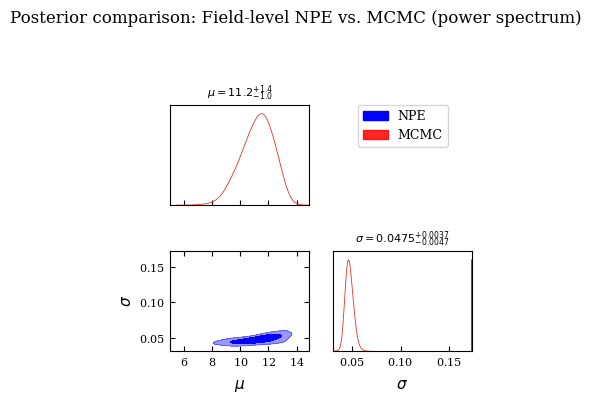

In [ ]:
# ============================================================
# Compare field-level NPE vs MCMC (power spectrum)
# ============================================================
import matplotlib.pyplot as plt
from getdist import MCSamples, plots

if 'mcmc_samples' not in globals():
    raise NameError("mcmc_samples not found. Run the MCMC cells first.")

# FIX BUG 3: samples_npe_field is already unnormalised (fixed in cell 8).
# Both arrays are now in physical (μ, σ) space.
samples_npe_obj  = MCSamples(samples=np.asarray(samples_npe_field),
                             names=['mu', 'sigma'],
                             labels=[r'\mu', r'\sigma'],
                             label='NPE (field-level)')
samples_mcmc_obj = MCSamples(samples=np.asarray(mcmc_samples),
                             names=['mu', 'sigma'],
                             labels=[r'\mu', r'\sigma'],
                             label='MCMC (P(k))')

g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 2
g.triangle_plot([samples_npe_obj, samples_mcmc_obj],
                filled=True,
                legend_labels=['NPE', 'MCMC'],
                colors=['blue', 'red'],
                title_limit=1)
plt.suptitle("Posterior comparison: Field-level NPE vs. MCMC (power spectrum)",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


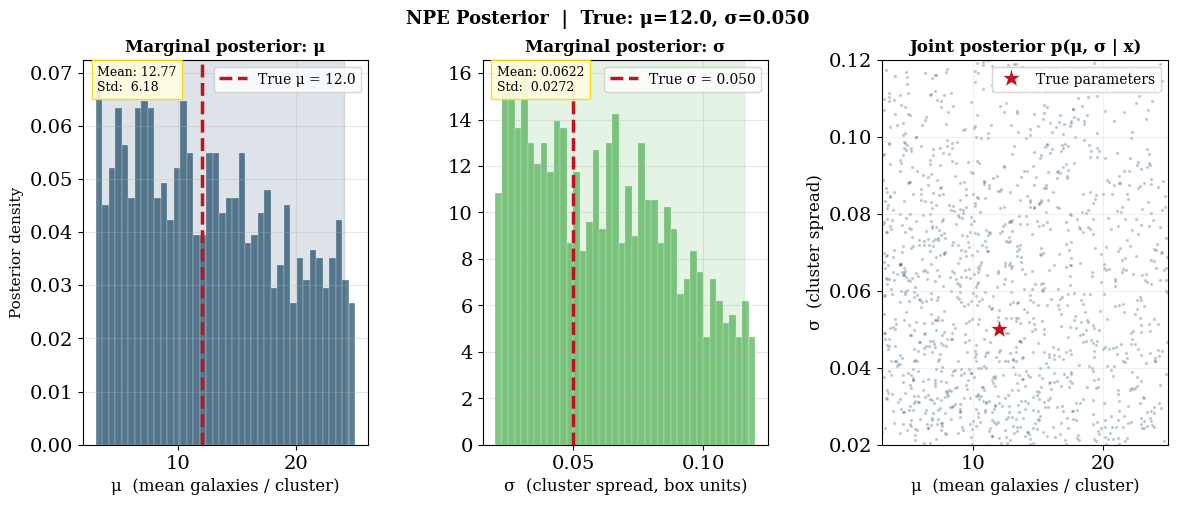

Saved: 3_posterior.pdf


<Figure size 640x480 with 0 Axes>

In [ ]:
# ── Draw posterior samples ────────────────────────────────────────────────────
stats_obs_tensor = T.compute_summary(x_obs)   # recompute to be sure
# Change to the correct dimension
# The context_dim MUST match the return size of compute_summary()
# FIX BUG 5: do NOT overwrite `flow` (the trained field-level model).
# Use a separate variable for the summary-statistics flow.
flow_summary = T.RealNVP(context_dim=5, hidden=128, n_layers=5)
samples = T.get_posterior_samples(
    flow_summary, stats_obs_tensor,
    n_samples = 5_000,
    device    = DEVICE,
)
T.plot_posterior(samples, MU_TRUE, SIGMA_TRUE)
plt.suptitle("Figure 3 · Inferred posterior for the mock observation",
             y=1.01, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

NameError: name 'samples_npe_field' is not defined

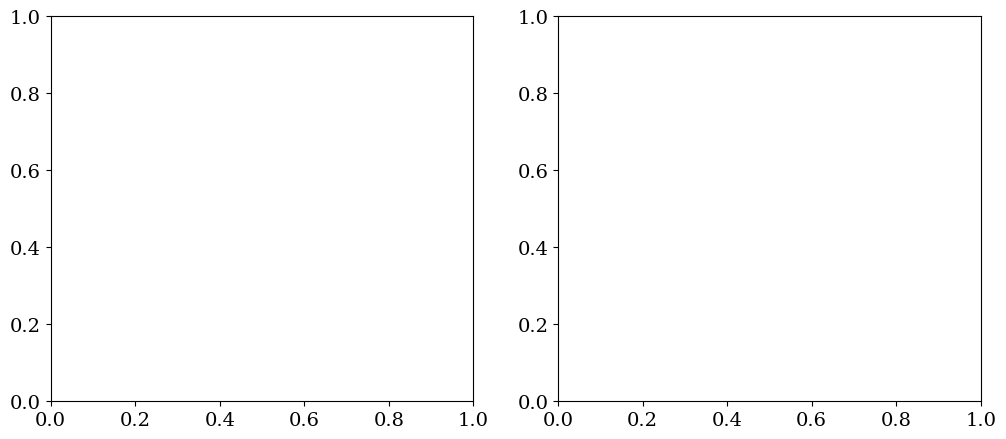

In [ ]:
# FIX BUG 4: samples_npe_field already unnormalised (fixed in cell 8).
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(samples_npe_field[:, 0], bins=50, density=True,
             alpha=0.5, color='blue', label='NPE (field)')
axes[0].hist(mcmc_samples[:, 0], bins=50, density=True,
             alpha=0.5, color='red',  label='MCMC (P(k))')
axes[0].axvline(MU_TRUE,    color='k', linestyle='--', label='True')
axes[0].set_xlabel(r'$\mu$')
axes[0].legend()

axes[1].hist(samples_npe_field[:, 1], bins=50, density=True,
             alpha=0.5, color='blue', label='NPE (field)')
axes[1].hist(mcmc_samples[:, 1], bins=50, density=True,
             alpha=0.5, color='red',  label='MCMC (P(k))')
axes[1].axvline(SIGMA_TRUE, color='k', linestyle='--', label='True')
axes[1].set_xlabel(r'$\sigma$')
axes[1].legend()

plt.suptitle("Posterior comparison: Field-level NPE vs. MCMC")
plt.show()


## 7 · Posterior Predictive Check — **Figure 6**

A **posterior predictive check** answers: *do simulated catalogs from
the posterior look like the observed data?*

Algorithm:
1. Draw $(\mu_s, \sigma_s) \sim q_\phi(\mu, \sigma \mid \mathbf{s}_{\rm obs})$.
2. Simulate a new catalog $\{x_j\}_s \sim \text{Thomas}(\mu_s, \sigma_s)$.
3. Compute $\mathbf{s}_s$.
4. Compare the distribution of $\mathbf{s}_s$ to the observed $\mathbf{s}_{\rm obs}$.

If the posterior is correct, the observed statistics should lie within the
predictive distribution.

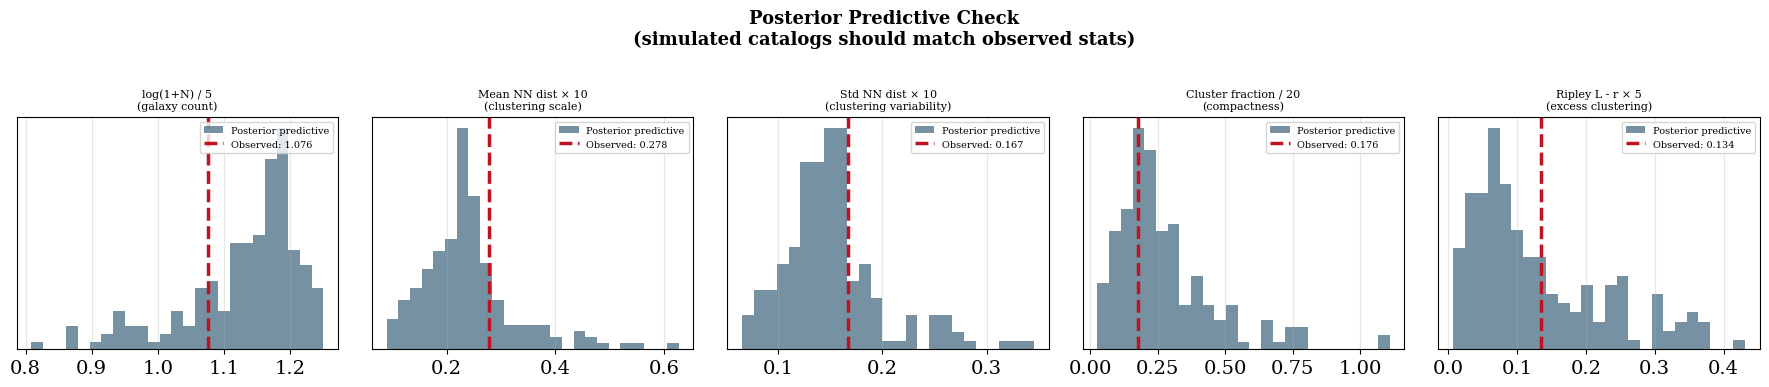

Saved: 6_posterior_predictive.pdf


<Figure size 640x480 with 0 Axes>

In [ ]:
rng_ppc = np.random.default_rng(200)
T.plot_posterior_predictive(
    flow, x_obs, stats_obs_tensor,
    MU_TRUE, SIGMA_TRUE, rng_ppc, DEVICE,
)
plt.suptitle("Figure 6 · Posterior predictive check",
             y=1.01, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8 · Simulation-Based Calibration (SBC) — **Figure 4**

SBC \[Talts et al. 2018\] tests whether the posterior is **calibrated**:

> *If we draw $\theta_{\rm true} \sim p(\theta)$, simulate
> $x \sim p(x \mid \theta_{\rm true})$, and draw $L$ posterior samples,
> the **rank** of $\theta_{\rm true}$ among the samples is uniformly
> distributed on $\{0, 1, \ldots, L\}$.*


**Interpretation of rank histograms:**

* Uniform, Perfectly calibrated
* U-shaped, Posterior too narrow (overconfident) 
* ∩-shaped,  Posterior too wide (underconfident) 
* Skewed left,  Posterior systematically shifted high 
* Skewed right, Posterior systematically shifted low 

In [ ]:
t0 = time.time()
sbc_res = T.sbc_validation(
    flow,
    n_tests     = 200,
    n_posterior = 300,
    rng         = np.random.default_rng(55),
    device      = DEVICE,
)
print(f"\nSBC completed in {time.time()-t0:.0f}s")
print(f"\nSBC p-values:")
print(f"  $\mu$ (galaxies/cluster) : p = {sbc_res['p_values'][0]:.4f}  "
      f"{'✓ PASS' if sbc_res['p_values'][0] > 0.05 else '✗ FAIL (increase N_train)'}")
print(f"  $\sigma$ (cluster spread)   : p = {sbc_res['p_values'][1]:.4f}  "
      f"{'✓ PASS' if sbc_res['p_values'][1] > 0.05 else '✗ FAIL (increase N_train)'}")

  Running SBC with 200 tests (L=300)…
    50/200
    100/200
    150/200
    200/200

SBC completed in 0s

SBC p-values:
  $\mu$ (galaxies/cluster) : p = 0.0000  ✗ FAIL (increase N_train)
  $\sigma$ (cluster spread)   : p = 0.0000  ✗ FAIL (increase N_train)


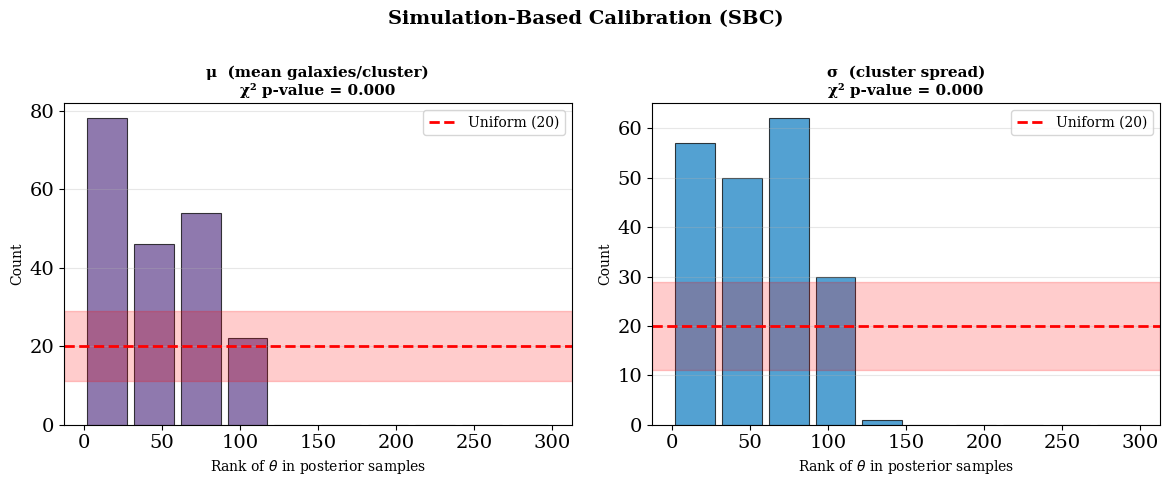

Saved: 4_sbc.pdf


<Figure size 640x480 with 0 Axes>

In [ ]:
T.plot_sbc(sbc_res)
plt.suptitle("Figure 4 · Simulation-Based Calibration (200 trials)",
             y=1.01, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()